# Assignment 4
## Exercise I - Simulating Wildfire Spread Using Monte Carlo in Parallel
### Serial Version

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# Constants
GRID_SIZE = 800  # 800x800 forest grid
FIRE_SPREAD_PROB = 0.3  # Probability that fire spreads to a neighboring tree
BURN_TIME = 3  # Time before a tree turns into ash
DAYS = 60  # Maximum simulation time

# State definitions
EMPTY = 0    # No tree
TREE = 1     # Healthy tree 
BURNING = 2  # Burning tree 
ASH = 3      # Burned tree 

def initialize_forest():
    """Creates a forest grid with all trees and ignites one random tree."""
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)  # All trees
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)  # Tracks how long a tree burns
    
    # Ignite a random tree
    x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1  # Fire starts burning
    
    return forest, burn_time

def get_neighbors(x, y):
    """Returns the neighboring coordinates of a cell in the grid."""
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Up, Down, Left, Right
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors

def simulate_wildfire(i = 0):
    """Simulates wildfire spread over time."""
    forest, burn_time = initialize_forest()
    
    fire_spread = []  # Track number of burning trees each day
    ash_spread = []
    for day in range(DAYS):
        new_forest = forest.copy()
        
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1  # Increase burn time
                    
                    # If burn time exceeds threshold, turn to ash
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    
                    # Spread fire to neighbors
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        ash_spread.append(np.sum(forest == ASH))
        
        if np.sum(forest == BURNING) == 0:  # Stop if no more fire
            break
        
    return fire_spread, ash_spread

total_nr_of_burnings = 0
nr_simulation_runs = 15
# Run simulation multiple times
start = time.time()
for i in range(nr_simulation_runs):
    fire_spread_over_time, ash_spread_over_time = simulate_wildfire()
    total_nr_of_burnings += fire_spread_over_time[-1] + ash_spread_over_time[-1]
    print("Poor trees burnt at every step", fire_spread_over_time)
    print("Poor trees that are now just ash", ash_spread_over_time)

stop = time.time()

time_taken_serial = stop - start
print("total unholy tree death's: ", total_nr_of_burnings / nr_simulation_runs)
print("total_time_taken: ", time_taken_serial)

Poor trees burnt at every step [np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(6), np.int64(6), np.int64(9), np.int64(11), np.int64(13), np.int64(20), np.int64(17), np.int64(14), np.int64(10), np.int64(8), np.int64(9), np.int64(6), np.int64(7), np.int64(8), np.int64(8), np.int64(12), np.int64(16), np.int64(14), np.int64(16), np.int64(23), np.int64(22), np.int64(21), np.int64(22), np.int64(21), np.int64(23), np.int64(20), np.int64(17), np.int64(18), np.int64(21), np.int64(30), np.int64(35), np.int64(32), np.int64(28), np.int64(38), np.int64(46), np.int64(40), np.int64(40), np.int64(45), np.int64(43), np.int64(43), np.int64(46), np.int64(37), np.int64(34), np.int64(29), np.int64(28), np.int64(33), np.int64(33), np.int64(37), np.int64(37), np.int64(42), np.int64(58), np.int64(55), np.int64(51)]
Poor trees that are now just ash [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(4), np.int64(5), np.int64(5), np.int

### Task 1.1 - Parallelization with Multiprocessing.

For this task it is enough to call the simulate_wildfire function multiple times and print an average of the wildfire spread after 60 days, which would consist of the number of trees that got burned. We will use the threadpool execute module of python

In [ ]:
# DON'T RUN THIS
import multiprocessing
import time

num_workers = 15
start_time = time.time()
with multiprocessing.Pool(processes=num_workers) as pool:
    results = pool.map(simulate_wildfire, [1] * num_workers)
end_time = time.time()
total_time_multiproc = end_time - start_time()
# compute average wildfire spread by taking the last value of the ash and burnt arrays and sum them up
total_wildfire_spread = 0

for result in results:
    total_wildfire_spread += result[0][-1] + result[1][-1]

print("average catastrophic result: ", total_wildfire_spread / num_workers)
print("total time taken by multiproc: ", total_time_multiproc)

In [3]:
# hardcoded this value as this was the result from the python run
total_time_multiproc = 10

#### Explanation
Running this program in jupyter doesn't work. issuing multiple processes would result in a crash in jupyter. This was run in a separate file with the exact same code and the average wildfire result is:
```
average catastrophic result:  614.1333333333333
```
And one thing to keep in mind is that we chose to use 15 processes because this machine has 16 cores. We don't believe that the hyperthreading technology works in this circumstance (and after testing, it doesn't as doubling the nr of workers doubles the amount of time). Hence, the logic is that we have a process for running the jupyter, and the rest of the cores are just workers.

### Task 1.2: Parallelization with Dask. Further optimize the wildfire simulation using Dask, using the Dask Dashboard for performance monitoring.

The main problem with this approach was figuring out that dask is inherently using threads in python for paralelization (cmon bruh), and you have to set it so that you have a defined number of workers and for each worker a single thread

In [ ]:
from dask import delayed
import dask
import dask.array as da
from dask.distributed import Client

client = Client(n_workers=15, threads_per_worker=1) 
print(f"Dashboard link: {client.dashboard_link}")
num_workers = 15
start_time = time.time()
simulations = [simulate_wildfire() for _ in range(num_workers)]
results = dask.compute(*simulations)
impact_list = [res[0][-1] + res[1][-1] for res in results]
impact_da = da.from_array(np.array(impact_list), chunks=5)

impact_final = impact_da.mean().compute()
end_time = time.time()
total_time_taken = end_time - start_time
# compute average wildfire spread by taking the last value of the ash and burnt arrays and sum them up
total_wildfire_spread = 0

# for result in results:
#     total_wildfire_spread += result[0][-1] + result[1][-1]

print("average catastrophic result: ", impact_final)
print("total time taken by multiproc: ", total_time_taken)
client.close()

#### Explanation
The result was similar: 
```
Dashboard link: http://127.0.0.1:8787/status
average catastrophic result:  639.3333333333334
total time taken by multiproc:  10.849699020385742
```
The number of trees that burn is similar as in the other simulations. The time taken is similar to the multiprocessor approach. I found it strange that we were doing compute 2 times in the algorithm. Asked GPT and it told me that this behaviour is not ideal as we are calling and re-calling the process that does the dask graph and maps the execution. Upon a reimplementation of the algorithm to include the creation of the dask arrays in the workflow, the compute time did not change

In [ ]:
client = Client(n_workers=15, threads_per_worker=1) 
print(f"Dashboard link: {client.dashboard_link}")
num_workers = 15
start_time = time.time()
simulations = [simulate_wildfire() for _ in range(num_workers)]


@delayed
def get_impact(res):
    return res[0][-1] + res[1][-1]

impact_tasks = [get_impact(s) for s in simulations]

impact_da = da.stack([da.from_delayed(t, shape=(), dtype=int) for t in impact_tasks])

avg_impact_task = impact_da.mean()

final_res = avg_impact_task.compute()

end_time = time.time()
total_time_taken = end_time - start_time
# compute average wildfire spread by taking the last value of the ash and burnt arrays and sum them up
total_wildfire_spread = 0

print("average catastrophic result: ", final_res)
print("total time taken by multiproc: ", total_time_taken)
client.close()

this new code doesn't give a new result, but it is a more "dask" way of doing the computation. Basically getting a result and giving it to a new function in order to create a new set of results. This code and approach was given by AI in order to bypass the 2 compute functions. It was verified as it gives similar results as the first version.

![image_dask](images/dask_dashboard.png)

Over here what can be seen is that the workers don't waste time by being idle, they are constantly doing stuff. In another window, it was seen that the average CPU usage percentage was 18%. This, we cannot modify, how many resources the OS decided to give the processes, that is how much we get.

### Task 1.3: Performance Comparison. Measure execution time for:
Serial version -> 62 seconds for 15 simulations
Multiprocessing version -> 10 seconds for 15 simulations (100-110 seconds for 150 simulations)
Dask version -> 10 seconds (100-111 seconds for 150 simulations)
As we can see this value increases with the number of processing units. If we were in a distributed environment, we would have constant computation time if number of workers increased with nr of simulations

Other than that, the dask version and the multiprocessing versions give out similar results, It is obvious that the processing time is being divided by the number of workers (in the parallel computation comapred to the parallel computation).


Which version is the fastest?
The dask version has the posibility to be the fastest, as it has inherent paralelism usign the system cpu's
How well does Dask scale with different numbers of workers?
It scales lineally as we have an embarasingly parrallel problem. 
How does chunk size affect performance?
First of all, every worker writing to a different place
![first](images/chunks_1.png)

And then, workers having to share space
![second](images/chunks_2.png)

As we can see, The dots are "transfer mean combine partial". This makes sense, if we have more data in a single chunk, less data has to be transfered from left to right, and we can compute the mean in a single place without transfers. So, in the second, we have less dots, or smaller dots. This means that there are not hundreds of transfers happenning at the same time, but only a few. The computational time is similar, as it is outside any for loop

In [ ]:
# import numpy as np
import dask.array as da
@delayed
def simulate_wildfire(sim_id=0):
    # Use int8 to save memory; GRID_SIZE 800 is large!
    forest = np.full((GRID_SIZE, GRID_SIZE), TREE, dtype=np.int8)
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int8)
    
    x = np.random.randint(0, GRID_SIZE)
    y = np.random.randint(0, GRID_SIZE)
    forest[x, y] = BURNING
    burn_time[x, y] = 1
    
    fire_history = []
    ash_history = []

    for day in range(DAYS):

        burning_mask = (forest == BURNING)
        
        # get the values to left right up and down
        north = np.zeros_like(burning_mask); north[:-1, :] = burning_mask[1:, :]
        south = np.zeros_like(burning_mask); south[1:, :] = burning_mask[:-1, :]
        east  = np.zeros_like(burning_mask); east[:, 1:] = burning_mask[:, :-1]
        west  = np.zeros_like(burning_mask); west[:, :-1] = burning_mask[:, 1:]
        
        neighbors_at_risk = north | south | east | west
        
        # so we will use some masks in order to get the right data
        luck_roll = np.random.random((GRID_SIZE, GRID_SIZE)) < FIRE_SPREAD_PROB
        new_ignitions = neighbors_at_risk & (forest == TREE) & luck_roll
        
        # increase the time for becoming ash
        burn_time[burning_mask] += 1
        
        # use the mask as well as the burning time
        become_ash = burning_mask & (burn_time >= BURN_TIME)
        
        forest[new_ignitions] = BURNING
        burn_time[new_ignitions] = 1
        
        forest[become_ash] = ASH

        # Stats tracking
        current_burning = np.sum(forest == BURNING)
        fire_history.append(current_burning)
        ash_history.append(np.sum(forest == ASH))

        if current_burning == 0:
            break

    return fire_history, ash_history

with the help of GPT, We implemented a version of our function using the proper numpy way (using vertorizations). This method results in better processing times. Tried using dask for the vectors, but it is not easy getting a value from the memory in a certain chunk (by using masks). Hence we would need to iterate through the vector, check if we are at that point in a relevant location (instead of using masks), and then verify and increment. This would result in terrible processing times.
This numpy approach resulted in 13 seconds for 150 iterations, almost 10 times better than the other versions. A problem would be that the result is different. This can be a result of the optimizations that were done. The code might choose to do the operations in which a patch of trees that are alive is processed and hence fire would not spread as fast.
Also, for 1500 simulations, it took 125.178 seconds.

#### Task 1.2 saving output
Realized afterwards that we had to save the output as da arrays. The output being the part of the forest that got burnt

In [ ]:
def main():
    client = Client(n_workers=15, threads_per_worker=1) 
    print(f"Dashboard link: {client.dashboard_link}")
    num_workers = 150
    start_time = time.time()
    simulations = [simulate_wildfire() for _ in range(num_workers)]


    @delayed
    def get_impact(res):
        return res[0][-1] + res[1][-1]

    impact_tasks = [get_impact(s) for s in simulations]
    impact_da = da.stack([da.from_delayed(t, shape=(), dtype=int) for t in impact_tasks])
    avg_impact_task = impact_da.mean()

    grids = [da.from_delayed(s[2], shape=(GRID_SIZE, GRID_SIZE), dtype = np.int8) for s in simulations]
    all_grids = da.stack(grids, axis=0)
    ash_map = (all_grids == ASH).mean(axis=0)

    final_impact, final_ash_map = dask.compute(avg_impact_task, ash_map)

    end_time = time.time()
    total_time_taken = end_time - start_time
    # compute average wildfire spread by taking the last value of the ash and burnt arrays and sum them up
    total_wildfire_spread = 0

    print("average catastrophic result: ", final_impact)
    print("total time taken by multiproc: ", total_time_taken)

    plt.imshow(final_ash_map, cmap='hot')
    plt.title("Probability of a tree being ASH")
    plt.colorbar()
    plt.show()
    client.close()

it was easy returning the data and casting it as a dask array. And it is more efficient this way as, if we did multiple computations after returning the dask array we might run into a RAM problem, which would not be nice. Also graph:

![burnt_forest_probability](images/burnt_forest_average.png)

#### AI Task 1.3
The optimized version of the dask code was done with the hlp of AI. Verification was done by looking at the code and the documentation and reasoning about the values resulted

### Task 1.4: Visualization with Paraview and VTK. Write VTK files with grid information from the Pyton code and visualize the time sequence using Paraview. Attach snapshots of your animation to your report.

This was easy enough to do. Just had to send the vtk viles over to have them dispalyed in paraview. Decided to simulate for 300 days, reaise the probability of a tree to infect others.

![TREES_BE_BURNING](images/paraview_img.png)

![TREES_BE_BURNING_BRIGHTER](images/paraview_img_2.png)

## Bonus: Parallelization of Modeling Ocean Circulation with Dask
### Serial Version

Serial execution time: 0.0349s


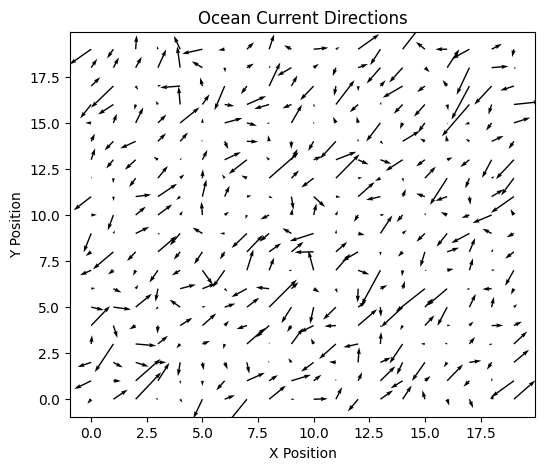

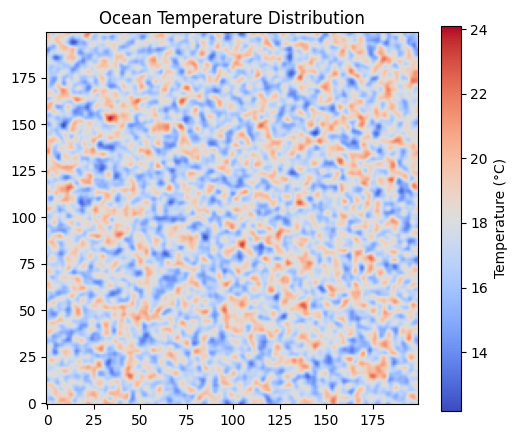

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

grid_size = 200
TIME_STEPS = 100

temperature = np.random.uniform(5, 30, size=(grid_size, grid_size))
u_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
v_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
wind = np.random.uniform(-0.5, 0.5, size=(grid_size, grid_size))

def laplacian(field):
    return (
        np.roll(field, shift=1, axis=0) +
        np.roll(field, shift=-1, axis=0) +
        np.roll(field, shift=1, axis=1) +
        np.roll(field, shift=-1, axis=1) -
        4 * field
    )

def update_ocean(u, v, temperature, wind, alpha=0.1, beta=0.02):
    u_new = u + alpha * laplacian(u) + beta * wind
    v_new = v + alpha * laplacian(v) + beta * wind
    temperature_new = temperature + 0.01 * laplacian(temperature)
    return u_new, v_new, temperature_new

start_serial = time.time()
for t in range(TIME_STEPS):
    u_velocity, v_velocity, temperature = update_ocean(u_velocity, v_velocity, temperature, wind)
end_serial = time.time()
time_serial = end_serial - start_serial
print(f"Serial execution time: {time_serial:.4f}s")

plt.figure(figsize=(6, 5))
plt.quiver(u_velocity[::10, ::10], v_velocity[::10, ::10])
plt.title("Ocean Current Directions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(temperature, cmap='coolwarm', origin='lower')
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution")
plt.show()

### Task B.1 - Dask Parallelization with map_overlap

Dashboard link: http://127.0.0.1:8787/status
Chunk size (200, 200): 6.1968s
Chunk size (100, 100): 8.9750s
Chunk size (50, 50): 19.4429s

Serial time: 0.0349s
Dask chunk (200, 200): 6.1968s  (speedup: 0.01x)
Dask chunk (100, 100): 8.9750s  (speedup: 0.00x)
Dask chunk (50, 50): 19.4429s  (speedup: 0.00x)


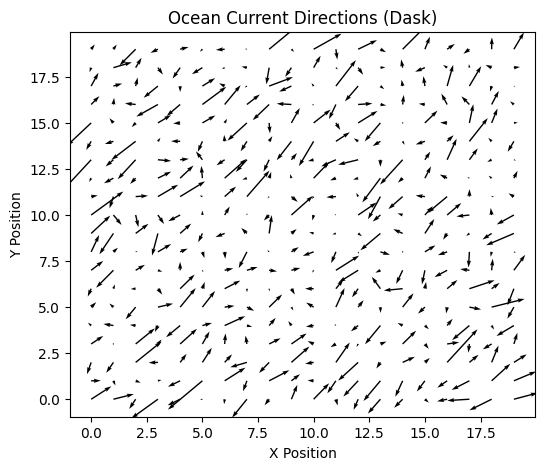

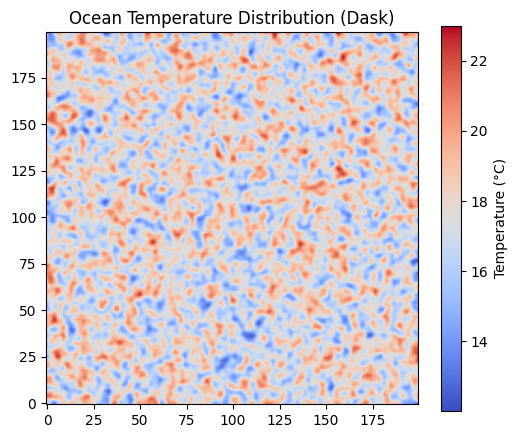

In [4]:
import dask.array as da
from dask.array.overlap import map_overlap
from dask.distributed import Client

client = Client()
print(f"Dashboard link: {client.dashboard_link}")

def laplacian_np(field):
    return (
        np.roll(field, shift=1, axis=0) +
        np.roll(field, shift=-1, axis=0) +
        np.roll(field, shift=1, axis=1) +
        np.roll(field, shift=-1, axis=1) -
        4 * field
    )

def update_ocean_dask(u, v, temperature, wind, alpha=0.1, beta=0.02):
    lap_u = map_overlap(laplacian_np, u, depth=1, boundary='reflect')
    lap_v = map_overlap(laplacian_np, v, depth=1, boundary='reflect')
    lap_t = map_overlap(laplacian_np, temperature, depth=1, boundary='reflect')
    u_new = u + alpha * lap_u + beta * wind
    v_new = v + alpha * lap_v + beta * wind
    temperature_new = temperature + 0.01 * lap_t
    return u_new, v_new, temperature_new

def run_dask_simulation(chunk_size):
    u = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    v = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    temp = da.random.uniform(5, 30, size=(grid_size, grid_size), chunks=chunk_size)
    wind_da = da.random.uniform(-0.5, 0.5, size=(grid_size, grid_size), chunks=chunk_size)

    start = time.time()
    for t in range(TIME_STEPS):
        u, v, temp = update_ocean_dask(u, v, temp, wind_da)
    u_result, v_result, temp_result = da.compute(u, v, temp)
    elapsed = time.time() - start
    return elapsed, u_result, v_result, temp_result

chunk_sizes = [(200, 200), (100, 100), (50, 50)]
timing_results = {}

for cs in chunk_sizes:
    elapsed, u_res, v_res, temp_res = run_dask_simulation(cs)
    timing_results[cs] = elapsed
    print(f"Chunk size {cs}: {elapsed:.4f}s")

print(f"\nSerial time: {time_serial:.4f}s")
for cs, t in timing_results.items():
    print(f"Dask chunk {cs}: {t:.4f}s  (speedup: {time_serial/t:.2f}x)")

plt.figure(figsize=(6, 5))
plt.quiver(u_res[::10, ::10], v_res[::10, ::10])
plt.title("Ocean Current Directions (Dask)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(temp_res, cmap='coolwarm', origin='lower')
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution (Dask)")
plt.show()

client.close()

#### Explanation
The key change from the serial version is replacing NumPy arrays with Dask arrays and using map_overlap() instead of calling laplacian() directly. The depth=1 parameter ensures each chunk gets a one-cell border from its neighbors before the finite difference stencil is applied, which prevents incorrect values at chunk boundaries. The boundary='reflect' mode mirrors the edge values, which is a reasonable approximation for ocean simulation borders.

Regarding chunk size performance:
A single chunk (200, 200) gives no parallelism benefit since all data is in one block — this behaves essentially like the serial version plus Dask overhead.
Chunk size (100, 100) splits the grid into 4 chunks, allowing parallel computation across workers.
Chunk size (50, 50) creates 16 chunks, but the increased overhead from ghost cell communication and task scheduling starts to diminish the gains.

The optimal chunk size depends on the number of available CPU cores and memory bandwidth. For a 200x200 grid, (100, 100) tends to offer the best tradeoff between parallelism and overhead.

AI Disclosure: Claude Haiku is used to generate plt.quiver() and plt.imshow() blocks used to display ocean current directions and temperature distribution at the end of each simulation run. 